# Iowa House Price Prediction - EDA

Workflow: construct the 47 specified regressors, audit and clean data, visualize `SalePrice`, and visualize numeric-regressor correlations.

## 1. Load data and construct the 47 specified regressors

The 47 regressors comprise 21 numeric features, ordinal `BsmtQual`, and 25 fixed `Neighborhood` indicators. `SalePrice` is the target.

In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

DATA_FILENAME = "IA_House_Price_Original_Data.xlsx"
DATA_CANDIDATES = [Path("../data") / DATA_FILENAME, Path("data") / DATA_FILENAME]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Could not find {DATA_FILENAME} in the repository data directory.")
TARGET = "SalePrice"
numeric_features = [
    "LotArea", "OverallQual", "OverallCond", "YearBuilt", "YearRemodAdd", "BsmtFinSF",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GrLivArea", "FullBath",
    "HalfBath", "BedroomAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageCars", "GarageArea",
    "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
]
continuous_features = [
    "LotArea", "YearBuilt", "YearRemodAdd", "BsmtFinSF", "BsmtUnfSF", "TotalBsmtSF",
    "1stFlrSF", "2ndFlrSF", "GrLivArea", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
]
neighbourhoods = [
    "Blmngtn", "Blueste", "BrDale", "BrkSide", "ClearCr", "CollgCr", "Crawfor", "Edwards",
    "Gilbert", "IDOTRR", "MeadowV", "Mitchel", "NAmes", "NPkVill", "NWAmes", "NoRidge",
    "NridgHt", "OldTown", "SWISU", "Sawyer", "SawyerW", "Somerst", "StoneBr", "Timber", "Veenker",
]
source_columns = [feature for feature in numeric_features if feature != "BsmtFinSF"] + ["BsmtFinSF1", "BsmtFinSF2", "BsmtQual", "Neighborhood", TARGET]

raw = pd.read_excel(DATA_PATH, skiprows=3)
raw.columns = raw.columns.astype(str).str.strip()
blank_layout_columns = raw.columns[raw.columns.str.startswith("Unnamed")].tolist()
raw = raw.drop(columns=blank_layout_columns)
missing_source_columns = sorted(set(source_columns) - set(raw.columns))
if missing_source_columns:
    raise KeyError(f"Required source columns are missing: {missing_source_columns}")
df = raw.loc[:, source_columns].copy()
print(f"Observations: {len(df):,}")
print(f"Blank layout columns removed: {blank_layout_columns}")
print(f"Selected source columns, including target: {df.shape[1]}")

Observations: 2,908
Blank layout columns removed: ['Unnamed: 81', 'Unnamed: 82']
Selected source columns, including target: 25


## 2. Check data status and clean data

This step checks column availability, duplicates and missing values, then constructs `BsmtFinSF`, maps `BsmtQual` (`Ex/Gd/TA/Fa/Po/NA` to `5/4/3/2/1/0`), and creates the 25 fixed neighborhood indicators.

In [22]:
data_status = pd.Series({
    "observations": len(df), "duplicate_rows": int(df.duplicated().sum()),
    "missing_target": int(df[TARGET].isna().sum()), "source_columns": df.shape[1],
})
display(data_status.to_frame("value"))

missingness = (df.isna().sum().to_frame("missing_count")
               .assign(missing_pct=lambda t: 100 * t["missing_count"] / len(df))
               .query("missing_count > 0").sort_values("missing_count", ascending=False))
display(missingness)

clean = df.copy()
clean["BsmtFinSF"] = clean["BsmtFinSF1"] + clean["BsmtFinSF2"]
bsmtqual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0}
clean["BsmtQual_ordinal"] = clean["BsmtQual"].fillna("NA").map(bsmtqual_map)

observed_neighbourhoods = set(clean["Neighborhood"].dropna())
if observed_neighbourhoods != set(neighbourhoods):
    raise ValueError("Neighborhood categories do not match the 25-feature specification.")
dummies = pd.get_dummies(clean["Neighborhood"], prefix="NBHD", dtype=int).reindex(
    columns=[f"NBHD_{name}" for name in neighbourhoods], fill_value=0
)
X_47 = pd.concat([clean[numeric_features], clean[["BsmtQual_ordinal"]], dummies], axis=1)
y = clean[TARGET].copy()
if X_47.isna().any().any() or y.isna().any():
    raise ValueError("Missing values remain; define a train-only imputation or exclusion rule before modelling.")
feature_status = pd.Series({
    "numeric_regressors": len(numeric_features), "ordinal_regressors": 1,
    "neighbourhood_indicators": dummies.shape[1], "total_regressors": X_47.shape[1],
    "missing_values_in_47_regressors": int(X_47.isna().sum().sum()),
})
display(feature_status.to_frame("value"))
assert X_47.shape[1] == 47

,value
observations,2908
duplicate_rows,4
missing_target,0
source_columns,25


,missing_count,missing_pct
BsmtQual,79,2.716644


,value
numeric_regressors,21
ordinal_regressors,1
neighbourhood_indicators,25
total_regressors,47
missing_values_in_47_regressors,0


## 3. Univariate analysis

This section examines each regressor's relationship with `SalePrice`. It is descriptive: it does not delete observations, transform the target, or select a final model.

In [23]:
discrete_features = [feature for feature in numeric_features if feature not in continuous_features]
continuous_y_summary = pd.DataFrame({
    "pearson_correlation_with_saleprice": X_47[continuous_features].corrwith(y, method="pearson"),
    "spearman_correlation_with_saleprice": X_47[continuous_features].corrwith(y, method="spearman"),
}).assign(abs_pearson=lambda table: table["pearson_correlation_with_saleprice"].abs())
continuous_y_summary = continuous_y_summary.sort_values("abs_pearson", ascending=False)
display(continuous_y_summary.round(3))

,pearson_correlation_with_saleprice,spearman_correlation_with_saleprice,abs_pearson
GrLivArea,0.721,0.725,0.721
TotalBsmtSF,0.659,0.607,0.659
GarageArea,0.651,0.662,0.651
1stFlrSF,0.640,0.579,0.640
YearBuilt,0.566,0.681,0.566
YearRemodAdd,0.541,0.602,0.541
BsmtFinSF,0.421,0.328,0.421
WoodDeckSF,0.328,0.363,0.328
OpenPorchSF,0.325,0.481,0.325
LotArea,0.272,0.433,0.272


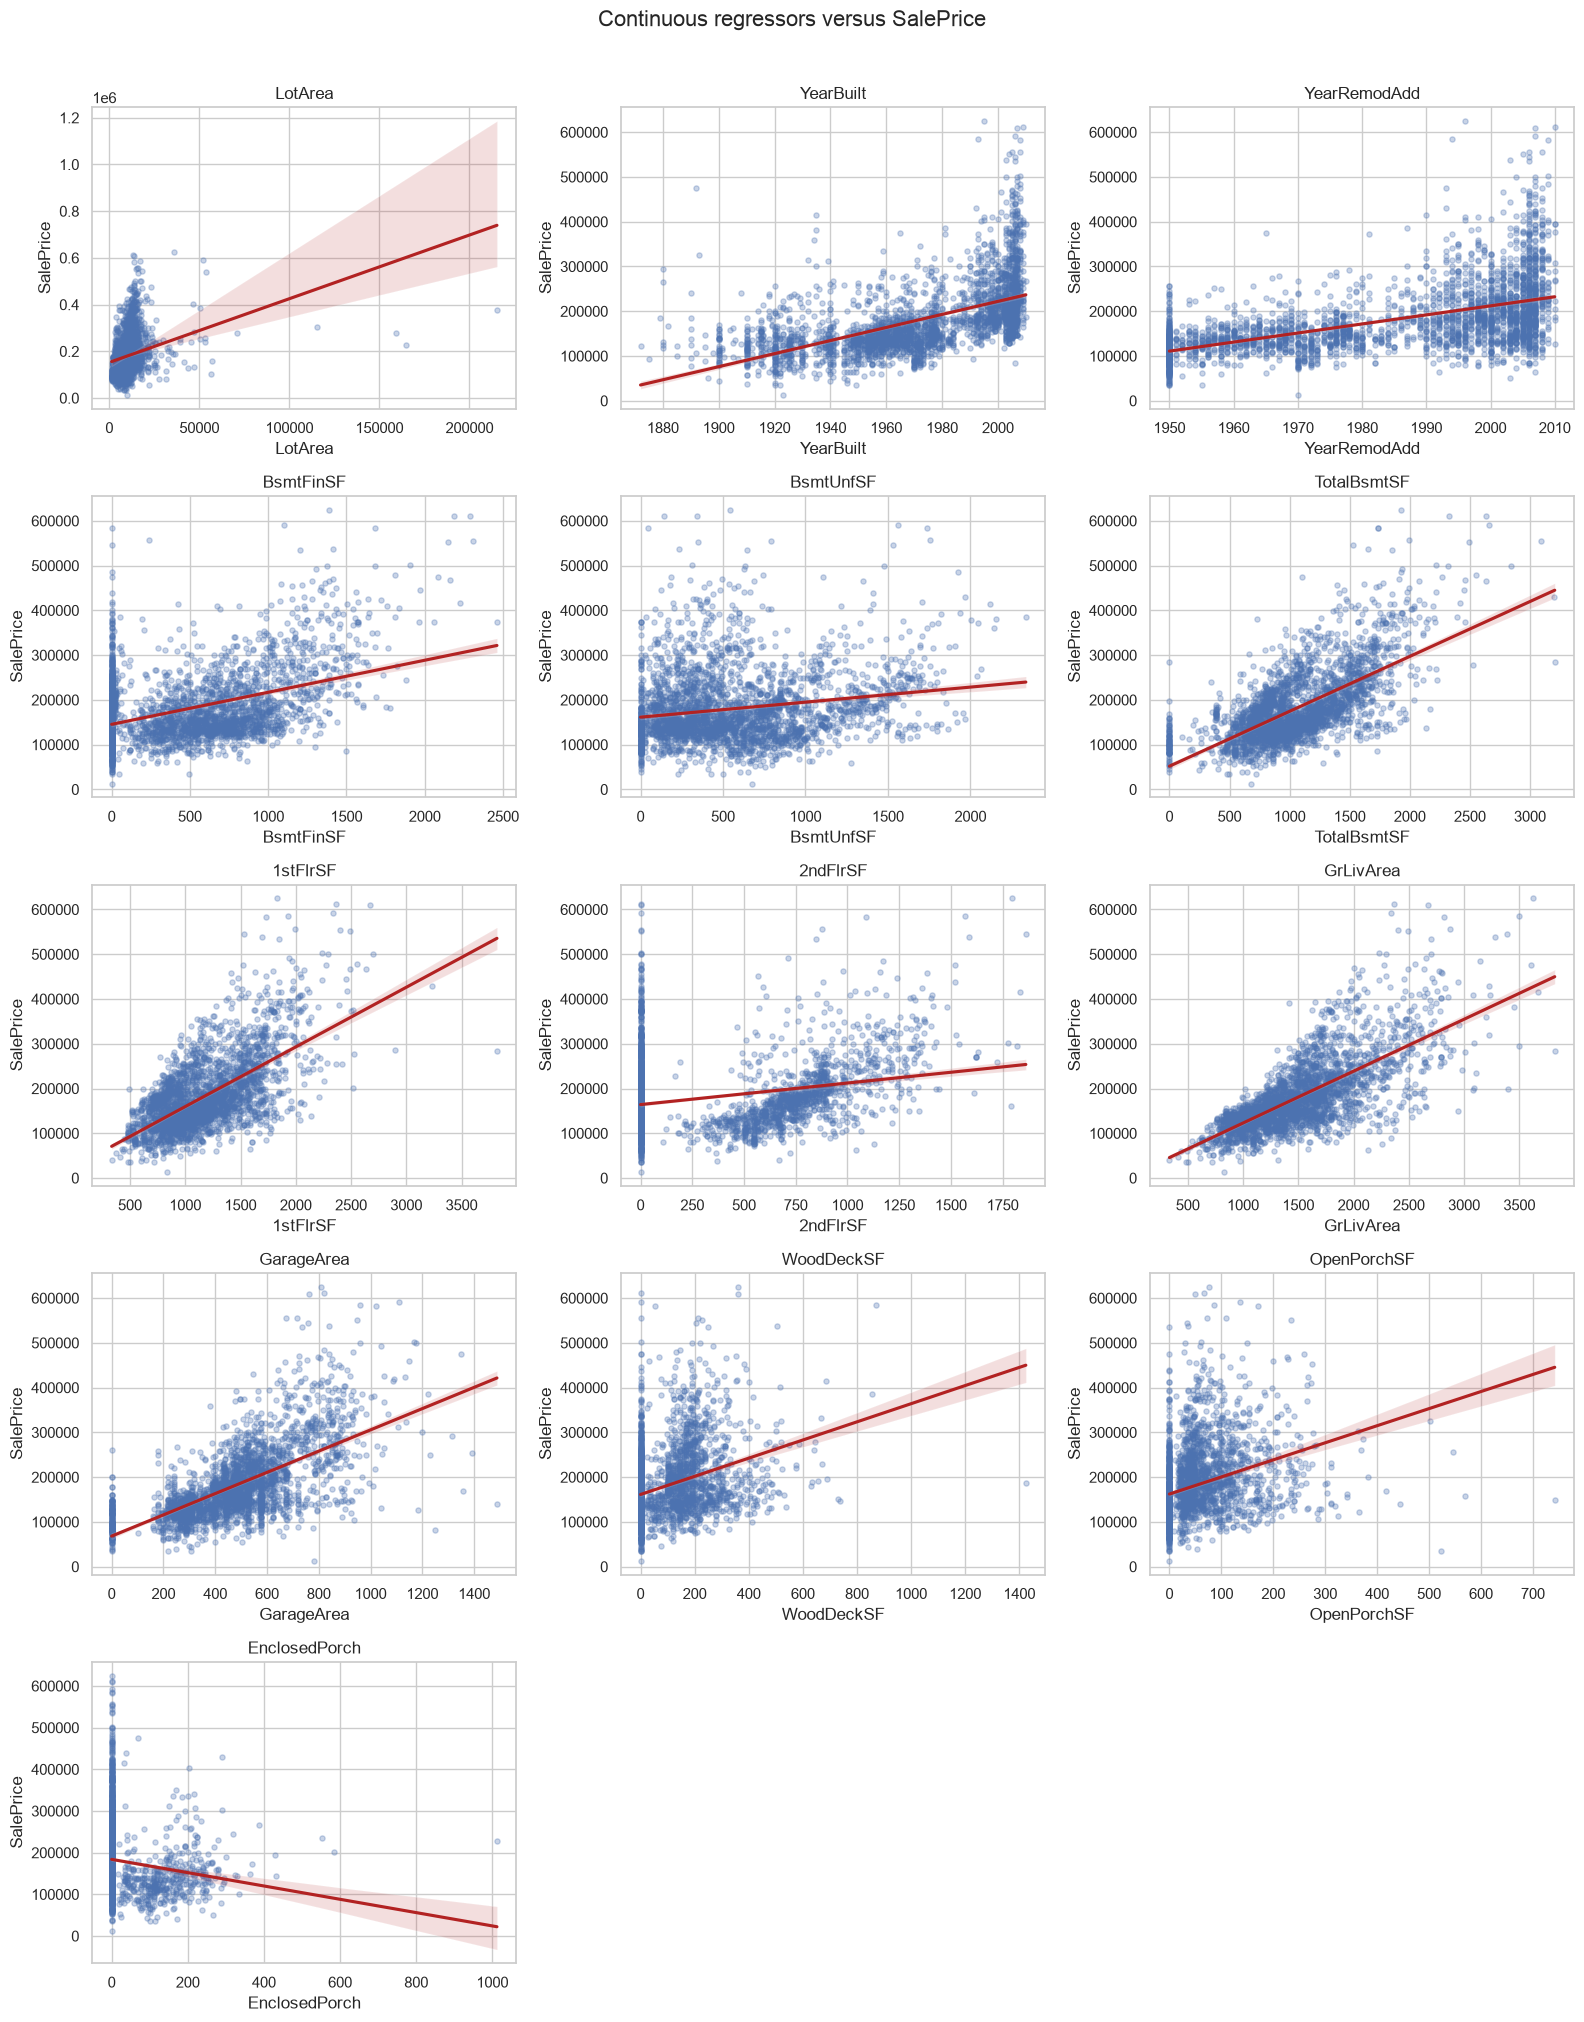

In [24]:
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
for feature, axis in zip(continuous_features, axes.flat):
    sns.regplot(data=pd.DataFrame({feature: X_47[feature], TARGET: y}), x=feature, y=TARGET,
                scatter_kws={"alpha": 0.30, "s": 14}, line_kws={"color": "firebrick"}, ax=axis)
    axis.set_title(feature)
for axis in axes.flat[len(continuous_features):]:
    axis.set_visible(False)
fig.suptitle("Continuous regressors versus SalePrice", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()


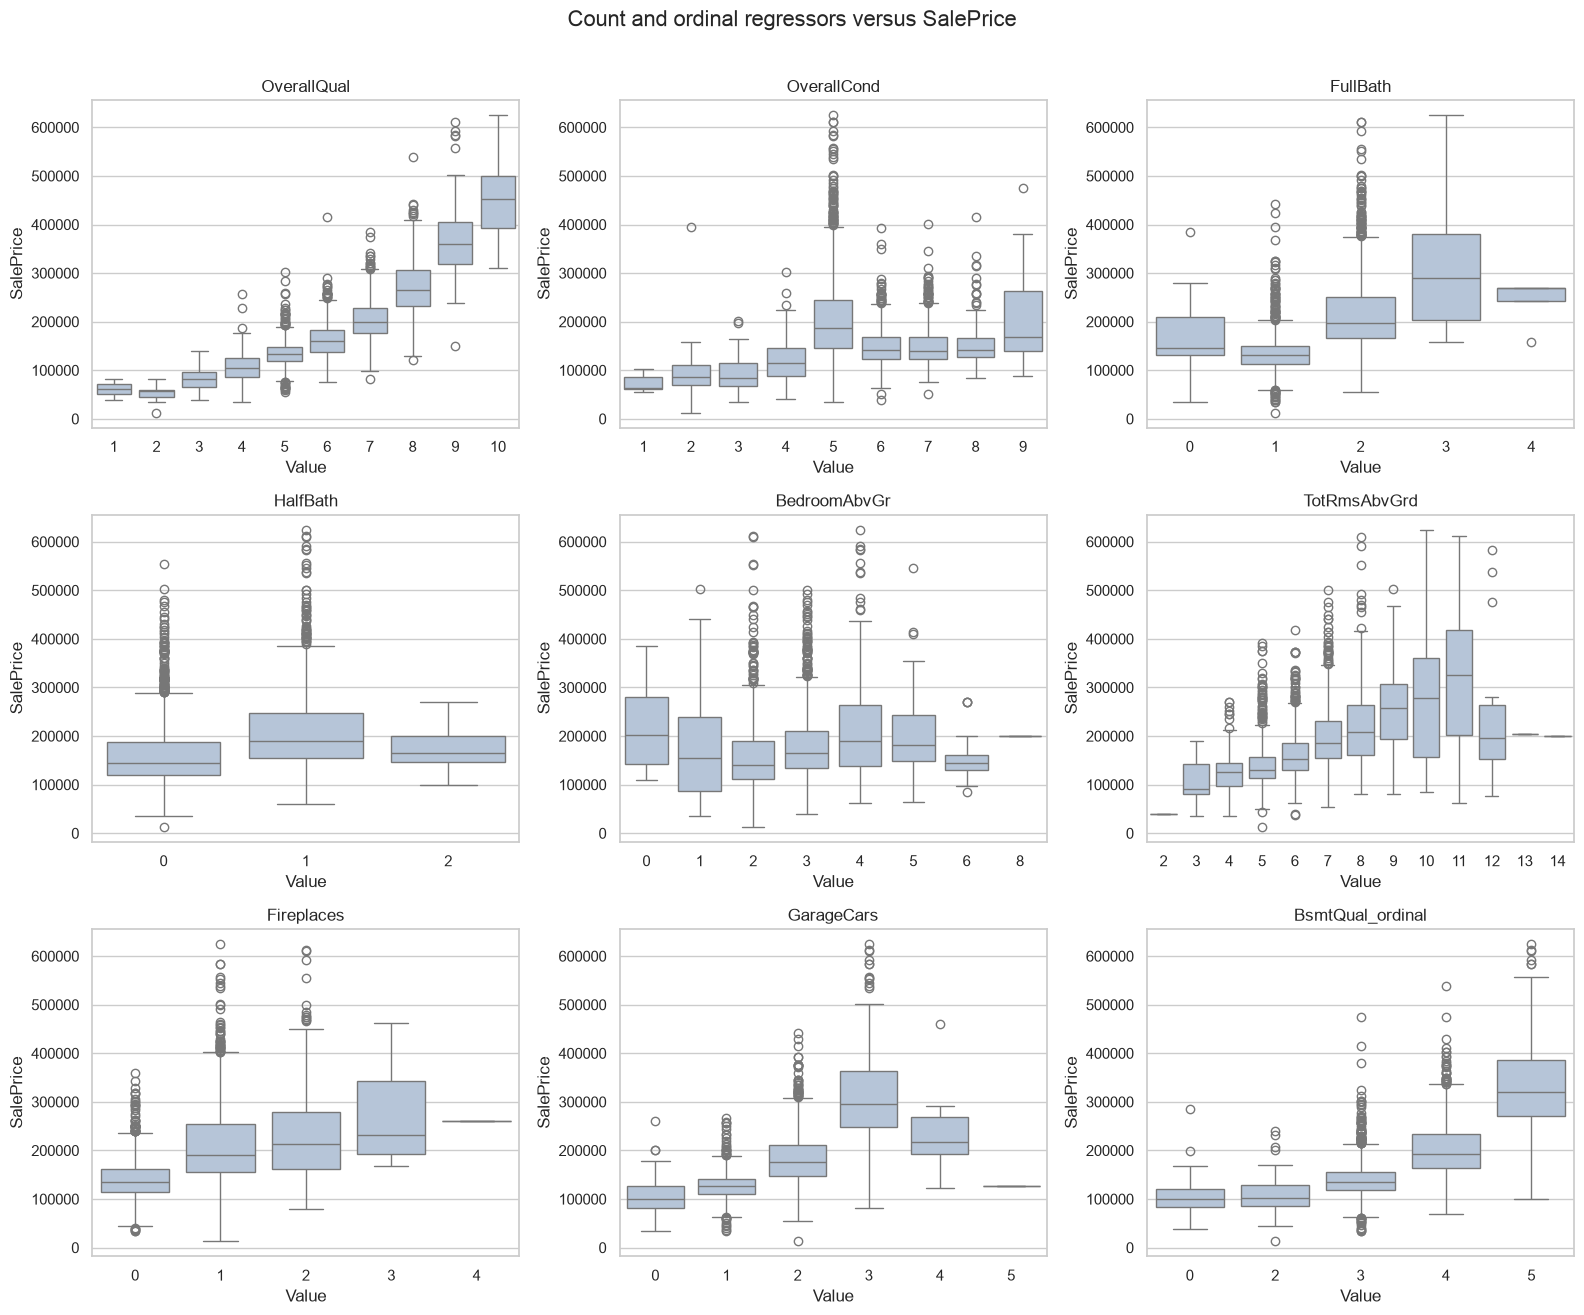

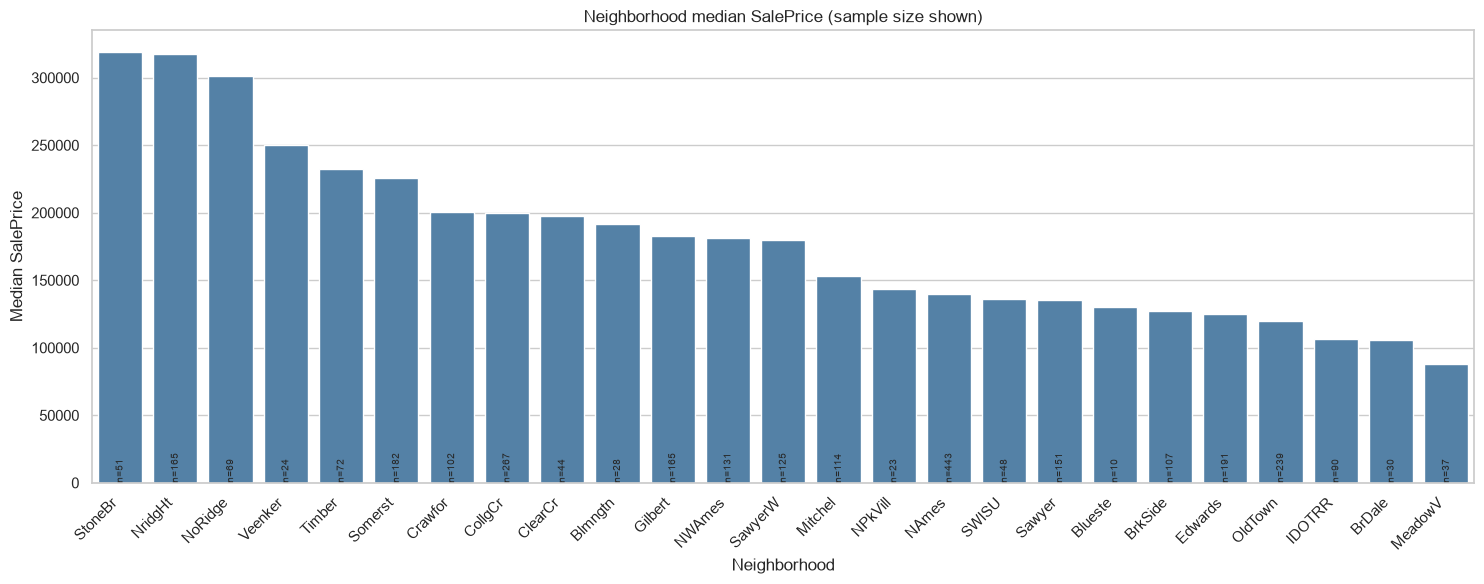

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for feature, axis in zip(discrete_features + ["BsmtQual_ordinal"], axes.flat):
    plot_data = pd.DataFrame({feature: X_47[feature], TARGET: y})
    sns.boxplot(data=plot_data, x=feature, y=TARGET, color="lightsteelblue", ax=axis)
    axis.set_title(feature)
    axis.set_xlabel("Value")
    axis.set_ylabel("SalePrice")
for axis in axes.flat[len(discrete_features) + 1:]:
    axis.set_visible(False)
fig.suptitle("Count and ordinal regressors versus SalePrice", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

neighbourhood_y = clean.groupby("Neighborhood")[TARGET].agg(observations="size", median_saleprice="median", mean_saleprice="mean").sort_values("median_saleprice", ascending=False)
plt.figure(figsize=(15, 6))
axis = sns.barplot(x=neighbourhood_y.index, y=neighbourhood_y["median_saleprice"], color="steelblue")
for position, observations in enumerate(neighbourhood_y["observations"]):
    axis.text(position, 0, f"n={observations}", ha="center", va="bottom", rotation=90, fontsize=7)
plt.title("Neighborhood median SalePrice (sample size shown)")
plt.xlabel("Neighborhood")
plt.ylabel("Median SalePrice")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Visualize the target distribution

`SalePrice` is shown in levels and log scale. This visualization does not choose the final target transformation.

,SalePrice
count,2908.000000
mean,180272.213549
std,78139.090808
min,12789.000000
25%,129362.500000
50%,160000.000000
75%,213310.000000
max,625000.000000


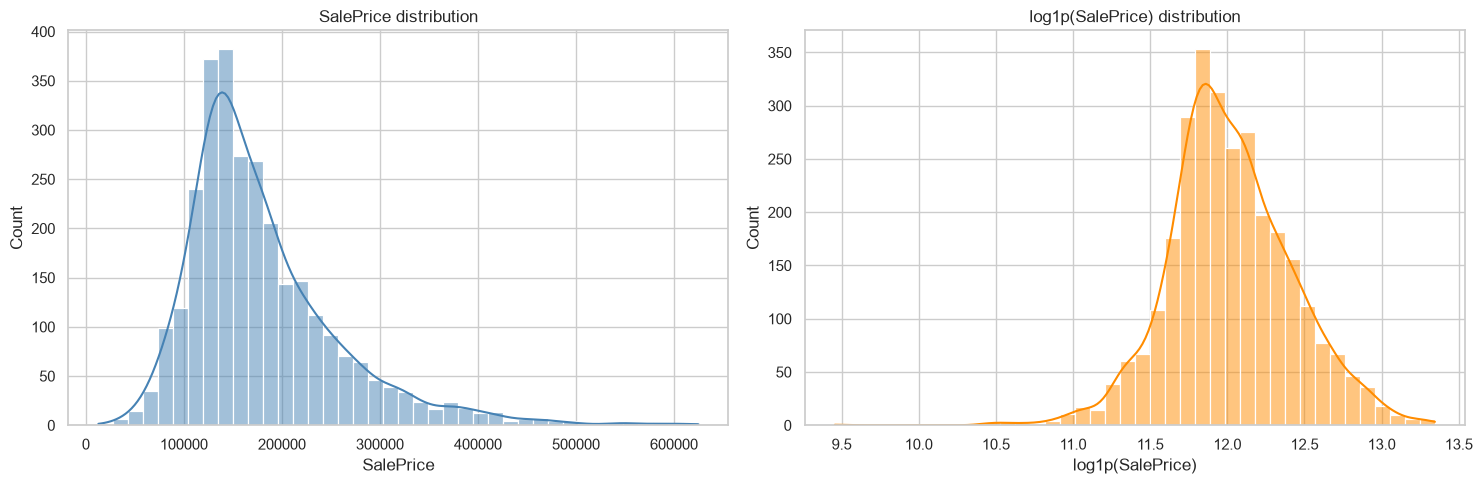

In [26]:
display(y.describe().to_frame(TARGET))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(y, bins=40, kde=True, color="steelblue", ax=axes[0])
axes[0].set(title="SalePrice distribution", xlabel="SalePrice")
sns.histplot(np.log1p(y), bins=40, kde=True, color="darkorange", ax=axes[1])
axes[1].set(title="log1p(SalePrice) distribution", xlabel="log1p(SalePrice)")
plt.tight_layout()
plt.show()

## 5. Visualize correlations among continuous regressors

The matrix uses only continuous regressors and excludes `SalePrice`, ordinal quality variables, count variables, and neighborhood dummies. Positive correlations are red, negative correlations are blue, and values close to zero are white.

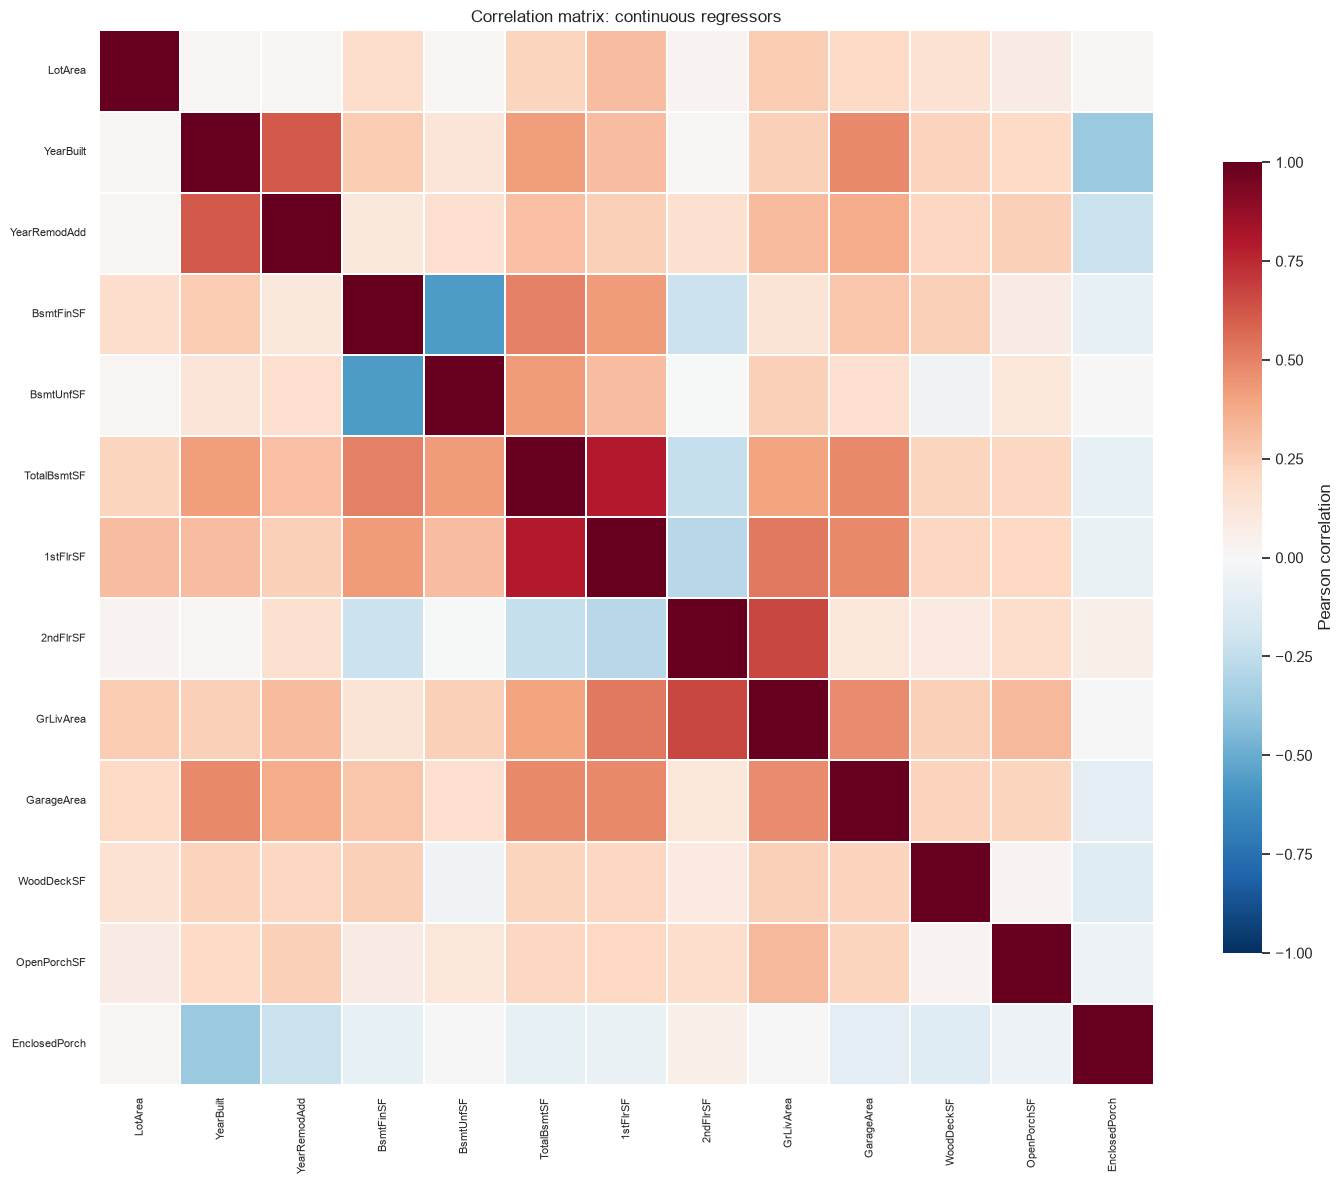

,,correlation,abs_correlation
TotalBsmtSF,1stFlrSF,0.789484,0.789484
2ndFlrSF,GrLivArea,0.664412,0.664412
YearBuilt,YearRemodAdd,0.611591,0.611591
BsmtFinSF,BsmtUnfSF,-0.565107,0.565107
1stFlrSF,GrLivArea,0.527698,0.527698
BsmtFinSF,TotalBsmtSF,0.503269,0.503269
1stFlrSF,GarageArea,0.482362,0.482362
YearBuilt,GarageArea,0.478887,0.478887
TotalBsmtSF,GarageArea,0.477684,0.477684
GrLivArea,GarageArea,0.475827,0.475827


In [27]:
continuous_correlation = X_47[continuous_features].corr(method="pearson")
plt.figure(figsize=(15, 12))
sns.heatmap(continuous_correlation, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.35, linecolor="white",
            cbar_kws={"shrink": 0.75, "label": "Pearson correlation"},
            xticklabels=True, yticklabels=True)
plt.title("Correlation matrix: continuous regressors")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

high_correlation_pairs = (continuous_correlation.where(np.triu(np.ones(continuous_correlation.shape), k=1).astype(bool))
                          .stack().rename("correlation").to_frame()
                          .assign(abs_correlation=lambda t: t["correlation"].abs())
                          .sort_values("abs_correlation", ascending=False))
display(high_correlation_pairs.head(15))